# Topic 7 - Example 2 - Transform $sinc(t-2)$

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Course utilities (do not modify this cell)        
import sys
import os
base_path = os.path.expanduser("~/Documents/GitHub/Signals_and_Systems")
sys.path.insert(0, base_path)
sys.path.insert(0, os.path.join(base_path, "courseutils"))

import basic_material as bm
print("Basic Material version:", bm.__version__)
bm.setup_environment()


Basic Material version: 16.002-0.1


In [3]:
colors = bm.get_colors()
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText

from sympy import lambdify, oo, Symbol, integrate, Heaviside, plot, Piecewise
from sympy import fourier_transform, exp, inverse_fourier_transform, sympify, DiracDelta, sinc, sin, cos, arg, atan2, re, cos, exp_polar, pi
from sympy.abc import A,B,t,f 
from sympy import re, im 

In [4]:
ts = Symbol('t')
def my_rect(p):
    return Piecewise((0, t <= -p/2),(1, t <= p/2),(0, True))

p = Symbol('p')
sincu = lambda t,p: sinc(p*pi*t) # swithc to sinc ftn that evetyone else uses...

In [5]:
tlim = 4
tt = np.linspace(-tlim, tlim, 1000)
flim = 2
ff = np.linspace(-flim, flim, 1000)

In [6]:
def my_sinc(tau=-2):
    sincuAB = lambda t, A, B: sinc(np.pi*(A*t + B))  # sinc everyone else uses
    if abs(tau) > 0:    
        lstr = f'sinc(t{tau:+g})'
    else:
        lstr = 'sinc(t)'
    nf1 = sincuAB(t, 1, tau)
    nQ1 = fourier_transform(nf1, t, f)

    lam_nf1    = lambdify(t, nf1,      modules=['numpy'])
    lam_absnQ1 = lambdify(f, abs(nQ1), modules=['numpy'])
    lam_argnQ1 = lambdify(f, arg(nQ1), modules=['numpy'])
    return lam_nf1, lam_absnQ1, lam_argnQ1, lstr


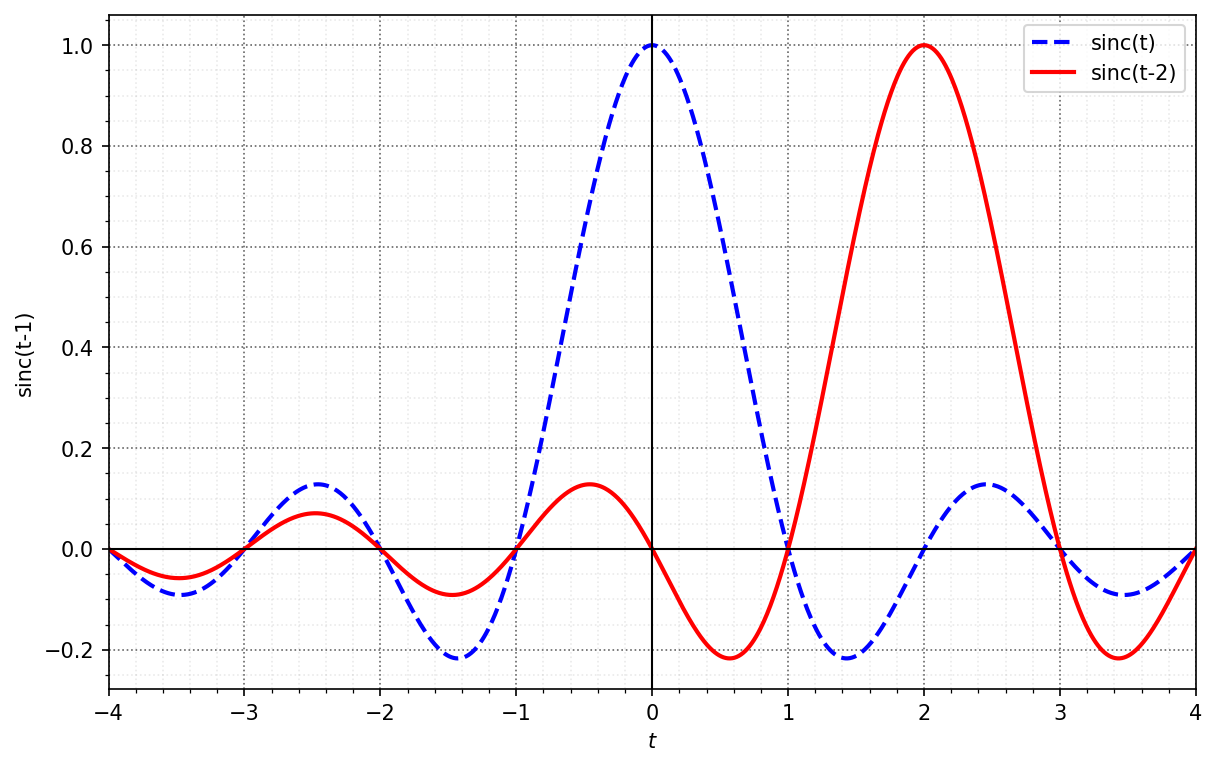

In [7]:
lam_nf1, lam_absnQ1, lam_argnQ1, lstr1 = my_sinc(tau=0)
lam_nf2, lam_absnQ2, lam_argnQ2, lstr2 = my_sinc(tau=-2)

fig = plt.figure(figsize=(8, 5),dpi=150,constrained_layout = True)
plt.plot(tt, lam_nf1(tt),'b--',label=lstr1)
plt.plot(tt, lam_nf2(tt),'r',label=lstr2)
plt.legend()
plt.xlim(-tlim,tlim)
plt.xlabel('$t$')
plt.ylabel('sinc(t-1)')
bm.nicegrid()
fig.savefig('./figs/T7_ex4_1.pdf', format='pdf', dpi=300)
plt.show()

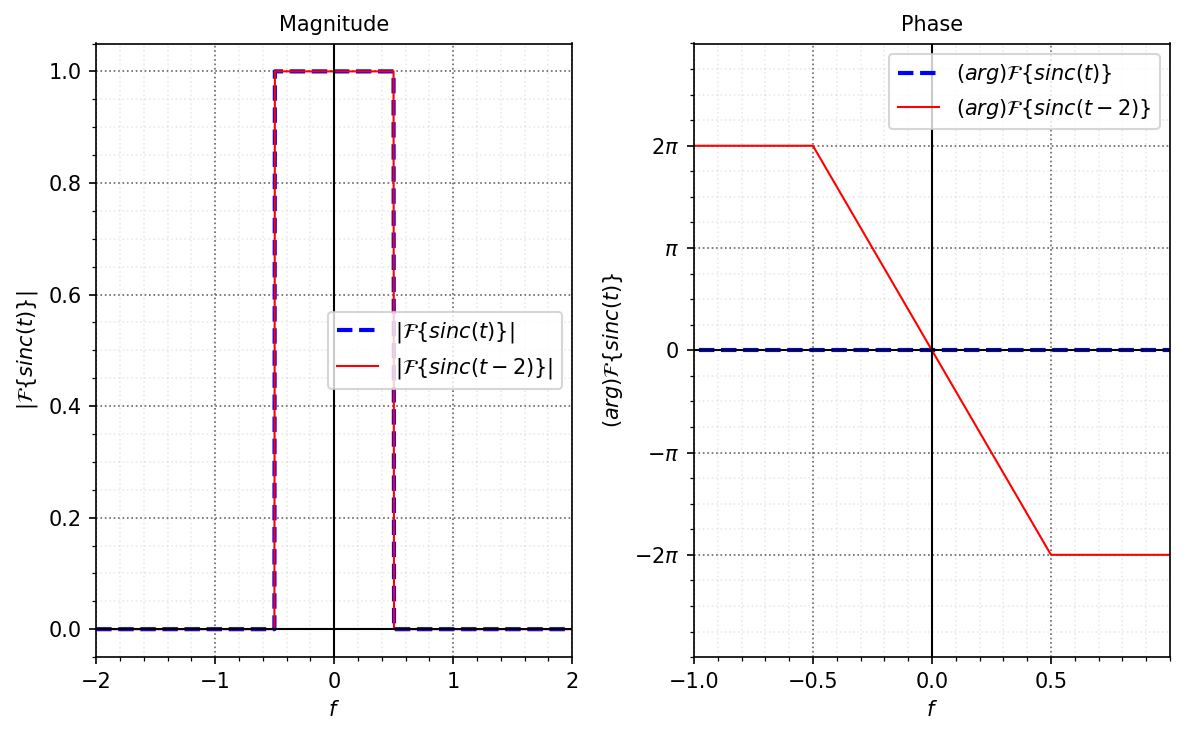

In [8]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,5), dpi=150)
ax1.plot(ff, lam_absnQ1(ff), 'b--', lw=2)
ax1.plot(ff, lam_absnQ2(ff), 'r-', lw=1)
ax1.set_title('Magnitude')
ax1.set_ylabel('$|{\cal F}\{'+lstr1+'\}|$')
ax1.set_xlabel('$f$')
bm.nicegrid(ax1)
ax1.legend(['$|{\cal F}\{'+lstr1+'\}|$', '$|{\cal F}\{'+lstr2+'\}|$'], loc=7)

ax2.plot(ff, np.unwrap(lam_argnQ1(ff)), 'b--', lw=2)
ax2.plot(ff, np.unwrap(lam_argnQ2(ff))+2*np.pi, 'r-', lw=1)
ax2.set_title('Phase')
ax2.set_ylabel('$(arg) {\cal F}\{'+lstr1+'\}$')
ax2.set_xlabel('$f$')
ax2.set_xlim(-1,1)
ax2.set_ylim(-3*np.pi, 3*np.pi)
ax2.set_yticks(np.arange(-2, 3, 1) * np.pi)
ax2.set_yticklabels([r'$-2\pi$', r'$-\pi$', '0', r'$\pi$', r'$2\pi$'])
ax2.legend(['$(arg) {\cal F}\{'+lstr1+'\}$', '$(arg) {\cal F}\{'+lstr2+'\}$'], loc=1)

ax2.set_xticks(np.arange(-1,1,0.5))

bm.nicegrid(ax2)
fig.savefig('./figs/T7_ex4_2.pdf', format='pdf', dpi=300)
plt.show()

### Recall: Based on time shift property, expected transform ${\tt sinc} (t-\tau) = e^{-2\pi f j \tau}{\tt rect}(f)$